In [1]:
"""
v8_multi_agent.py
-------------------
Personal Investment Research Assistant -- MULTI-AGENT version.

v7 built ONE agent that loops between reasoning and tool-calling until it
has an answer. This version splits that single agent into SEVERAL
SPECIALIST agents that hand off to each other:

    SUPERVISOR    -- reads the question, decides whether it needs fresh
                     data (-> research_agent) or can be answered generally
                     (-> advisor_agent directly, skipping research entirely)

    RESEARCH AGENT -- gathers data via tools (price, company info, news),
                     THEN decides itself whether the question warrants a
                     risk analysis (-> risk_agent) or can go straight to
                     the advisor (-> advisor_agent)

    RISK AGENT    -- reasons over the research notes to flag risk factors
                     (concentration, volatility signals, valuation extremes),
                     always hands off to advisor_agent

    ADVISOR AGENT -- synthesizes whatever's available (research notes,
                     risk notes, or neither) into one final answer, ends
                     the run

WHAT'S NEW IN THIS VERSION: Command(goto=...)

Every previous version routed with add_conditional_edges: a SEPARATE
decision function, wired to a node at graph-build time, external to the
node itself. Here, each node makes its OWN routing decision as part of its
own return value -- Command(update={...}, goto="next_node_name") both
updates state AND says where to go next, in one return. There is no
add_conditional_edges call anywhere in this file's graph-build section --
routing lives entirely inside the nodes.

This matters when the routing decision is naturally part of the work a
node is already doing (e.g. "I just researched this stock and now I can
tell whether risk analysis is warranted") rather than a separate,
reusable check performed on the node's output from the outside.
"""

import os
from typing import Optional, List, Annotated, TypedDict, Literal
import operator

from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langchain_together import ChatTogether
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

import yfinance as yf


# ---------------------------------------------------------------------------
# 1. TOOLS (same as v7 -- reused here for the Research Agent's inline loop)
# ---------------------------------------------------------------------------

@tool
def get_stock_price(ticker: str) -> str:
    """Get the current price and today's percent change for a stock ticker."""
    try:
        info = yf.Ticker(ticker).info
        price = info.get("currentPrice") or info.get("regularMarketPrice")
        prev_close = info.get("previousClose")
        if price is None:
            return f"Could not find price data for ticker '{ticker}'."
        change_pct = ((price - prev_close) / prev_close * 100) if prev_close else None
        change_str = f"{change_pct:+.2f}%" if change_pct is not None else "unknown change"
        return f"{ticker.upper()}: ${price:.2f} ({change_str} today)"
    except Exception as e:
        return f"Error fetching price for '{ticker}': {e}"


@tool
def get_stock_info(ticker: str) -> str:
    """Get company name, sector, market cap, and 52-week price range for a stock ticker."""
    try:
        info = yf.Ticker(ticker).info
        name = info.get("longName", ticker.upper())
        sector = info.get("sector", "unknown sector")
        market_cap = info.get("marketCap")
        low52 = info.get("fiftyTwoWeekLow")
        high52 = info.get("fiftyTwoWeekHigh")
        market_cap_str = f"${market_cap / 1e9:.1f}B" if market_cap else "unknown"
        return (
            f"{name} ({ticker.upper()}) -- Sector: {sector}. "
            f"Market cap: {market_cap_str}. 52-week range: ${low52} - ${high52}."
        )
    except Exception as e:
        return f"Error fetching info for '{ticker}': {e}"


@tool
def get_stock_news(ticker: str) -> str:
    """Get a few recent news headlines for a stock ticker."""
    try:
        news_items = yf.Ticker(ticker).news or []
        headlines = []
        for item in news_items[:3]:
            title = item.get("content", {}).get("title") or item.get("title")
            if title:
                headlines.append(f"- {title}")
        return f"Recent headlines:\n" + "\n".join(headlines) if headlines else "No recent news found."
    except Exception as e:
        return f"Error fetching news for '{ticker}': {e}"


TOOLS = [get_stock_price, get_stock_info, get_stock_news]
TOOLS_BY_NAME = {t.name: t for t in TOOLS}



C:\Users\Pandiyan\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from dotenv import load_dotenv
load_dotenv(".env")
# ---------------------------------------------------------------------------
# 2. LLM SETUP
# ---------------------------------------------------------------------------

TOGETHER_MODEL = "Qwen/Qwen2.5-7B-Instruct-Turbo"

llm = ChatTogether(
    model=TOGETHER_MODEL,
    temperature=0,
    together_api_key=os.getenv("TOGETHER_API_KEY"),
)

llm_with_tools = llm.bind_tools(TOOLS)


In [5]:

# ---------------------------------------------------------------------------
# 3. GRAPH STATE
#    `path` uses a reducer (operator.add) purely for OBSERVABILITY in the
#    demo: each node appends its own name so we can print, after the run,
#    exactly which agents were visited for a given question -- making the
#    dynamic routing decisions from Command(goto=...) visible rather than
#    just asserted.
# ---------------------------------------------------------------------------

class MultiAgentState(TypedDict):
    user_question: str
    research_notes: Optional[str]
    risk_notes: Optional[str]
    final_answer: Optional[str]
    path: Annotated[List[str], operator.add]


In [7]:

# ---------------------------------------------------------------------------
# 4. NODE: supervisor
#    First real Command(goto=...) decision. Looks at the question and
#    decides whether fresh research is warranted at all. A question that
#    doesn't name a specific stock has nothing concrete to research, so it
#    skips STRAIGHT to the advisor -- research_agent and risk_agent never
#    run for that kind of question.
#
#    The return type annotation `Command[Literal["research_agent",
#    "advisor_agent"]]` is not enforced at runtime (LangGraph routes based
#    on whatever `goto` value the function actually returns) -- it exists
#    so tools like draw_mermaid_png() can show the possible destinations in
#    the graph diagram, since there's no add_conditional_edges call here to
#    read that information from.
# ---------------------------------------------------------------------------

SUPERVISOR_PROMPT = """Does the following question require looking up CURRENT data about a
specific company or stock ticker (price, news, company details)? Or is it a
general question that can be answered without looking anything up?

Respond with EXACTLY ONE WORD: "RESEARCH" or "GENERAL".

Question: {question}
"""


def supervisor(state: MultiAgentState) -> Command[Literal["research_agent", "advisor_agent"]]:
    classification = llm.invoke(
        SUPERVISOR_PROMPT.format(question=state["user_question"])
    ).content.strip().upper()

    next_node = "advisor_agent" if "GENERAL" in classification else "research_agent"
    return Command(update={"path": ["supervisor"]}, goto=next_node)



In [9]:

# ---------------------------------------------------------------------------
# 5. NODE: research_agent
#    Runs its OWN small tool-calling loop inline (not a separate ToolNode --
#    v7 already covered that mechanism in depth; this version deliberately
#    shows a different, simpler way to let one node use tools without
#    needing a second node just to execute them).
#
#    After gathering data, decides for itself whether the ORIGINAL question
#    sounds like it's asking about risk/safety/volatility. If so, hand off
#    to risk_agent; otherwise skip straight to advisor_agent. This is the
#    SECOND dynamic Command(goto=...) decision in this graph.
# ---------------------------------------------------------------------------

MAX_TOOL_ITERATIONS = 4


def research_agent(state: MultiAgentState) -> Command[Literal["risk_agent", "advisor_agent"]]:
    messages = [
        SystemMessage("You are a research assistant. Use tools to gather factual data "
                       "about the stock(s) mentioned in the question, then summarize what you found."),
        HumanMessage(state["user_question"]),
    ]

    for _ in range(MAX_TOOL_ITERATIONS):
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        if not response.tool_calls:
            break
        for call in response.tool_calls:
            tool_fn = TOOLS_BY_NAME.get(call["name"])
            result = tool_fn.invoke(call["args"]) if tool_fn else f"Unknown tool: {call['name']}"
            messages.append(ToolMessage(content=str(result), tool_call_id=call["id"]))

    research_notes = messages[-1].content or "No research summary was produced."

    risk_keywords = ("risk", "risky", "volatil", "safe", "safety", "dangerous")
    needs_risk_analysis = any(word in state["user_question"].lower() for word in risk_keywords)
    next_node = "risk_agent" if needs_risk_analysis else "advisor_agent"

    return Command(
        update={"research_notes": research_notes, "path": ["research_agent"]},
        goto=next_node,
    )



In [11]:

# ---------------------------------------------------------------------------
# 6. NODE: risk_agent
#    No real branching decision here -- it always hands off to
#    advisor_agent. Still expressed as Command(goto=...) for consistency
#    with the rest of the graph, but worth being explicit: a plain
#    builder.add_edge("risk_agent", "advisor_agent") would behave
#    IDENTICALLY here, since there's no decision being made. Command(goto=)
#    earns its place in supervisor/research_agent, where the destination
#    genuinely varies -- not here.
# ---------------------------------------------------------------------------

RISK_PROMPT = """Based on this research about a stock, identify 2-3 brief risk factors an
individual investor should be aware of (e.g. sector concentration, volatility,
valuation extremes, small market cap). Be concise -- a few short bullet points.

Research notes:
{research_notes}
"""


def risk_agent(state: MultiAgentState) -> Command[Literal["advisor_agent"]]:
    risk_notes = llm.invoke(
        RISK_PROMPT.format(research_notes=state.get("research_notes", "None available."))
    ).content

    return Command(
        update={"risk_notes": risk_notes, "path": ["risk_agent"]},
        goto="advisor_agent",
    )



In [13]:

# ---------------------------------------------------------------------------
# 7. NODE: advisor_agent
#    The only node that can route to END. Synthesizes whatever's available
#    -- research notes, risk notes, both, or neither (the GENERAL-question
#    path from supervisor never populates either) -- into one final answer.
# ---------------------------------------------------------------------------

ADVISOR_PROMPT = """Answer the user's question as a helpful personal investment research
assistant. Use the research and risk notes below if they're relevant --
if both say "None available", just answer from general knowledge, briefly.

User's question: {question}

Research notes:
{research_notes}

Risk notes:
{risk_notes}
"""


def advisor_agent(state: MultiAgentState) -> Command[Literal["__end__"]]:
    final_answer = llm.invoke(
        ADVISOR_PROMPT.format(
            question=state["user_question"],
            research_notes=state.get("research_notes") or "None available.",
            risk_notes=state.get("risk_notes") or "None available.",
        )
    ).content

    return Command(
        update={"final_answer": final_answer, "path": ["advisor_agent"]},
        goto=END,
    )



In [15]:

# ---------------------------------------------------------------------------
# 8. BUILD THE GRAPH
#    Notice there is NO add_conditional_edges call, and no add_edge calls
#    between the four agent nodes -- every transition after START is
#    decided inside the nodes themselves via Command(goto=...). The only
#    fixed edge is START -> supervisor, since every run has to begin
#    somewhere.
# ---------------------------------------------------------------------------

builder = StateGraph(MultiAgentState)

builder.add_node("supervisor", supervisor)
builder.add_node("research_agent", research_agent)
builder.add_node("risk_agent", risk_agent)
builder.add_node("advisor_agent", advisor_agent)

builder.add_edge(START, "supervisor")

graph = builder.compile(checkpointer=InMemorySaver())



In [17]:

# ---------------------------------------------------------------------------
# 9. VISUALIZE THE GRAPH
#    The diagram will show all four possible destinations (research_agent,
#    risk_agent, advisor_agent, END) even though any single run only
#    actually visits SOME of them -- that's expected: the diagram shows the
#    graph's SHAPE (every possible path), not one execution's trace.
# ---------------------------------------------------------------------------

def visualize_graph(compiled_graph, output_path: str = "graph_v8.png") -> None:
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
    except Exception as e:
        print(f"Graph visualization failed (mermaid/graphviz dependency issue?): {e}")
        return

    try:
        from IPython.display import Image, display
        from IPython import get_ipython
        if get_ipython() is not None:
            display(Image(png_bytes))
            return
    except ImportError:
        pass

    with open(output_path, "wb") as f:
        f.write(png_bytes)
    print(f"Graph diagram saved to: {output_path}")



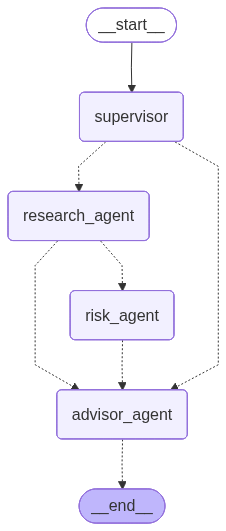


QUESTION: What's the current price of NVIDIA stock?

Route taken: supervisor -> research_agent -> advisor_agent

Final answer:
The current price of NVIDIA stock (NVDA) is $194.83, which is a decrease of 1.39% compared to the previous closing price. As of this information, there are no specific risk notes available for NVIDIA.

QUESTION: Is investing in Tesla stock risky right now?

Route taken: supervisor -> research_agent -> risk_agent -> advisor_agent

Final answer:
Investing in Tesla stock right now does carry significant risk. Here are the key factors to consider:

1. **Earnings Report**: Tesla's Q4 earnings report showed a net loss of $2.38 billion, which missed analysts' estimates. While revenue was slightly above expectations at $16.39 billion, the financial challenges are notable.

2. **Production Delays**: There are delays at Tesla's planned Gigafactory in Berlin, which could lead to production setbacks and supply chain disruptions. This could impact the company's ability to 

In [19]:

# ---------------------------------------------------------------------------
# 10. QUICK TEST -- three questions, chosen to exercise THREE DIFFERENT
#     routes through the graph:
#       Q1 -- names a specific stock, no risk language
#             -> supervisor -> research_agent -> advisor_agent
#       Q2 -- names a specific stock, WITH risk language
#             -> supervisor -> research_agent -> risk_agent -> advisor_agent
#       Q3 -- general question, no specific stock
#             -> supervisor -> advisor_agent   (research/risk both skipped)
# ---------------------------------------------------------------------------

QUESTIONS = [
    "What's the current price of NVIDIA stock?",
    "Is investing in Tesla stock risky right now?",
    "What's a reasonable percentage of my portfolio to keep in cash?",
]


def ask(question: str, thread_id: str) -> MultiAgentState:
    config = {"configurable": {"thread_id": thread_id}}
    initial_state = {
        "user_question": question,
        "research_notes": None,
        "risk_notes": None,
        "final_answer": None,
        "path": [],
    }
    return graph.invoke(initial_state, config)


if __name__ == "__main__":
    visualize_graph(graph)

    for i, question in enumerate(QUESTIONS):
        print("\n" + "=" * 70)
        print(f"QUESTION: {question}")
        print("=" * 70)

        result = ask(question, thread_id=f"multi-agent-{i}")

        print(f"\nRoute taken: {' -> '.join(result['path'])}")
        print(f"\nFinal answer:\n{result['final_answer']}")
